<a href="https://colab.research.google.com/github/sekhahelina/ML_tasks/blob/main/Module2/HW_2_4_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%B1%D1%83%D1%81%D1%82%D0%B8%D0%BD%D0%B3%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [ ]:
raw_df = pd.read_csv("/content/drive/MyDrive/dataframes/Bank/train.csv", index_col=0)
data = split_train_val(raw_df, ['Exited'])
data

(       CustomerId      Surname  CreditScore Geography  Gender   Age  Tenure  \
 id                                                                            
 7180   15652218.0         Mays        682.0    France    Male  30.0     1.0   
 10393  15592937.0       Ch'eng        684.0    France  Female  39.0     2.0   
 80     15774586.0        Ch'in        705.0   Germany    Male  35.0     6.0   
 3365   15780572.0           K?        669.0     Spain    Male  58.0     0.0   
 12236  15642099.0    Trevisani        707.0    France    Male  21.0     3.0   
 ...           ...          ...          ...       ...     ...   ...     ...   
 9493   15711299.0    Onyekachi        633.0    France  Female  33.0     4.0   
 8463   15778418.0         Tsao        673.0    France  Female  40.0     1.0   
 8143   15585192.0         Hsia        621.0    France    Male  29.0     8.0   
 11512  15694450.0       Onuora        590.0     Spain    Male  42.0     7.0   
 9360   15636413.0  Ponomaryova        5

In [ ]:
train_df, val_df = split_train_val(raw_df, ['Exited'])

In [ ]:
input_cols = raw_df.drop(['Exited', 'CustomerId', 'Surname'], axis = 1).columns.tolist()
target_col = "Exited"
input_cols, target_col

(['CreditScore',
  'Geography',
  'Gender',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 'Exited')

In [ ]:
X_train, train_targets = separate_inputs_targets(train_df, input_cols, target_col)
print(X_train.shape, train_targets.shape)
X_val, val_targets = separate_inputs_targets(val_df, input_cols, target_col)
print(X_val.shape, val_targets.shape)

(12000, 10) (12000,)
(3000, 10) (3000,)


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 7180 to 9360
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      12000 non-null  float64
 1   Geography        12000 non-null  object 
 2   Gender           12000 non-null  object 
 3   Age              12000 non-null  float64
 4   Tenure           12000 non-null  float64
 5   Balance          12000 non-null  float64
 6   NumOfProducts    12000 non-null  float64
 7   HasCrCard        12000 non-null  float64
 8   IsActiveMember   12000 non-null  float64
 9   EstimatedSalary  12000 non-null  float64
dtypes: float64(8), object(2)
memory usage: 1.0+ MB


1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [ ]:
cat_features = X_train.select_dtypes(include='object').columns
X_train[cat_features] = X_train[cat_features].astype('category')
X_val[cat_features] = X_val[cat_features].astype('category')

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 7180 to 9360
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      12000 non-null  float64 
 1   Geography        12000 non-null  category
 2   Gender           12000 non-null  category
 3   Age              12000 non-null  float64 
 4   Tenure           12000 non-null  float64 
 5   Balance          12000 non-null  float64 
 6   NumOfProducts    12000 non-null  float64 
 7   HasCrCard        12000 non-null  float64 
 8   IsActiveMember   12000 non-null  float64 
 9   EstimatedSalary  12000 non-null  float64 
dtypes: category(2), float64(8)
memory usage: 867.4 KB


In [ ]:
X_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3000 entries, 6490 to 3024
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      3000 non-null   float64 
 1   Geography        3000 non-null   category
 2   Gender           3000 non-null   category
 3   Age              3000 non-null   float64 
 4   Tenure           3000 non-null   float64 
 5   Balance          3000 non-null   float64 
 6   NumOfProducts    3000 non-null   float64 
 7   HasCrCard        3000 non-null   float64 
 8   IsActiveMember   3000 non-null   float64 
 9   EstimatedSalary  3000 non-null   float64 
dtypes: category(2), float64(8)
memory usage: 217.0 KB


2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [ ]:
!wget -c https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh

--2026-07-31 08:49:16--  https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.32.241, 104.16.191.158, 2606:4700::6810:20f1, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.32.241|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 197272282 (188M) [application/octet-stream]
Saving to: ‘Miniconda3-latest-Linux-x86_64.sh’

Miniconda3-latest-L 100%[===================>] 188.13M   247MB/s    in 0.8s    

2026-07-31 08:49:17 (247 MB/s) - ‘Miniconda3-latest-Linux-x86_64.sh’ saved [197272282/197272282]



In [ ]:
н!chmod +x Miniconda3-latest-Linux-x86_64.sh

In [ ]:
!bash ./Miniconda3-latest-Linux-x86_64.sh -b -f -p /usr/local

PREFIX=/usr/local
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /usr/local


In [ ]:
!conda install -c conda-forge xgboost

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ done
Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: | / - \ done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - xgboost


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.7.22  |       hbd8a1cb_0         129 KB  conda-forge
    certifi-2026.7.22          |     pyhd8ed1ab_0         134 KB  conda-forge
    conda-26.5.3               |  py314h9e666f3_2         1.4 MB  conda-forge
    cuda-version-12.9          |       h4f385c5_3          21 KB  conda-forge
    joblib-1.5.3               |     pyhd8ed1ab_0         221 KB  conda-forge
    libblas-3.11.0   

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score

In [ ]:

def compute_auroc_and_build_roc(model, inputs, targets, name='', plot: bool = True):
  # Predict probabilities
  probs = model.predict_proba(inputs)[:, 1]
  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, probs)
  # Compute AUROC
  roc_auc = auc(fpr, tpr)

  print(f'AUROC for {name}: {roc_auc:.4f}')

  if plot:
        plt.figure(figsize=(6, 4))
        plt.plot(
            fpr,
            tpr,
            color='darkorange',
            lw=2,
            label=f'ROC curve (AUC = {roc_auc:.4f})'
        )
        plt.plot([0, 1], [0, 1], linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve ({name})')
        plt.legend(loc='lower right')
        plt.show()

  return

AUROC for Training: 0.9292


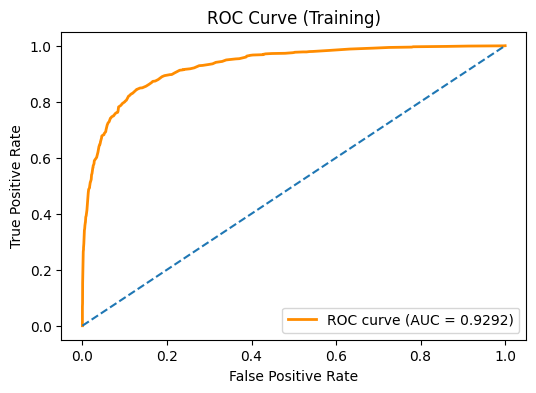

None
AUROC for Validation: 0.9285


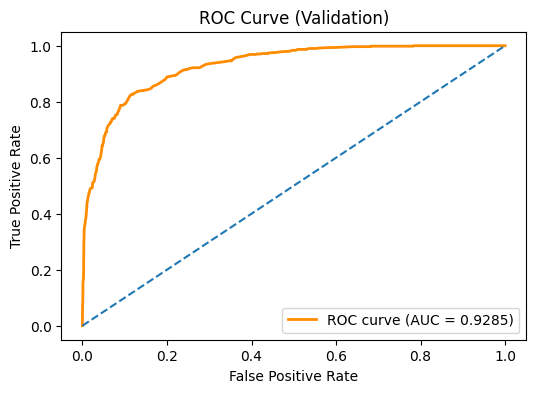

None


In [ ]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    max_depth=2,
    n_estimators=15,
    enable_categorical=True,
    missing=np.nan,
    device='cuda'
)

xgb_clf.fit(X_train, train_targets)
train_preds = xgb_clf.predict(X_train)
val_preds = xgb_clf.predict(X_val)

print(compute_auroc_and_build_roc(xgb_clf, X_train, train_targets, "Training"))
print(compute_auroc_and_build_roc(xgb_clf, X_val, val_targets, "Validation"))

Модель доволі хороша, немає ознак перенавчання, AUROC для валідаційного набору майже не змінився порівняно з деревами.

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [ ]:
!pip install hyperopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 973.5/973.5 kB 33.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 80.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [hyperopt]


In [ ]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.metrics import roc_auc_score

In [ ]:
?XGBClassifier

100%|██████████| 20/20 [00:04<00:00,  4.23trial/s, best loss: -0.9381555662253928]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.6497300338480558), 'gamma': np.float64(0.03901029543418805), 'learning_rate': np.float64(0.0780143366555197), 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 480, 'reg_alpha': np.float64(0.3506832932733329), 'reg_lambda': np.float64(0.10308206613656157), 'subsample': np.float64(0.6624745156815548)}
Точність на валідаційній вибірці: 0.9319
AUROC for Training: 0.9686


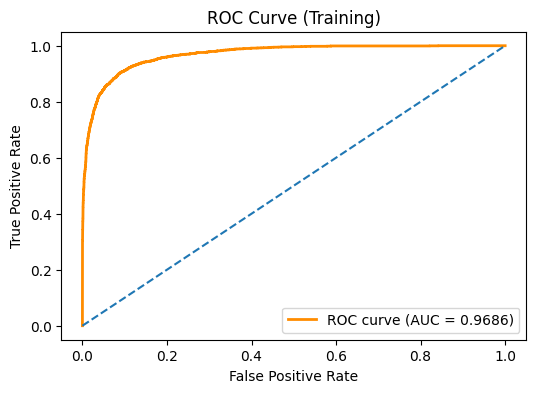

None
AUROC for Validation: 0.9319


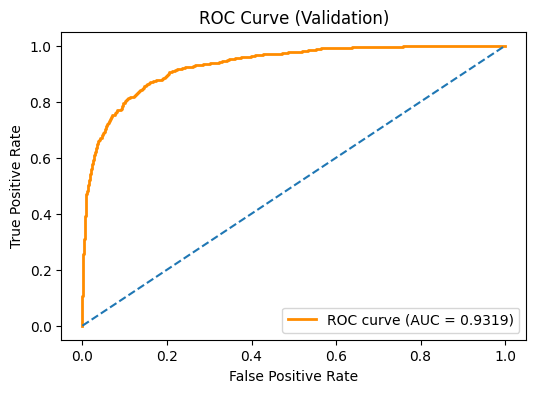

None


In [ ]:
def objective(params):
    clf = xgb.XGBClassifier(
    n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        gamma=params['gamma'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        enable_categorical=True,
        missing=np.nan,
        device='cuda',
        early_stopping_rounds=10,
        random_state=42
    )

    clf.fit(
        X_train,
        train_targets,
        eval_set=[(X_val, val_targets)],
        verbose=False)
    pred_proba = clf.predict_proba(X_val)[:, 1]
    roc_auc = roc_auc_score(val_targets, pred_proba)

    return {'loss': -roc_auc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 20),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 15, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials, rstate=np.random.default_rng(42))

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    missing=np.nan,
    device='cuda',
    random_state=42
)

final_clf.fit(X_train, train_targets)
final_pred_proba = final_clf.predict_proba(X_val)[:, 1]
final_roc_auc = roc_auc_score(val_targets, final_pred_proba)
print("Точність на валідаційній вибірці: {:.4f}".format(final_roc_auc))
print(compute_auroc_and_build_roc(final_clf, X_train, train_targets, "Training"))
print(compute_auroc_and_build_roc(final_clf, X_val, val_targets, "Validation"))

Після підбору гіперпараметрів якість моделі покращилася. Модель є хорошою.

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [ ]:
%%bash
sudo apt-get update
sudo apt-get install -y build-essential cmake git wget unzip
sudo apt-get install -y libboost-dev libboost-system-dev libboost-filesystem-dev
sudo apt-get install -y libboost-iostreams-dev libboost-program-options-dev libboost-regex-dev
sudo apt-get install -y libboost-thread-dev libboost-chrono-dev libboost-date-time-dev
sudo apt-get install -y libboost-atomic-dev libboost-serialization-dev
sudo apt-get install -y python3-pip

In [ ]:
%%bash
sudo apt-get install -y ocl-icd-libopencl1 clinfo
sudo apt-get install -y nvidia-opencl-dev opencl-headers

In [ ]:
%%bash
git clone --recursive https://github.com/microsoft/LightGBM
cd LightGBM
mkdir build
cd build
cmake -DUSE_CUDA=1 ..
make -j4

In [ ]:
%%bash
cd /content/LightGBM/python-package

In [ ]:
import lightgbm as lgb
print(lgb.__version__)

4.6.0


In [ ]:
cat_feature_indexes = [X_train.columns.get_loc(col) for col in cat_features]
cat_feature_indexes

[1, 2]

[LightGBM] [Warning] categorical_feature is set with cat_feature=1,2, categorical_column=1,2 will be ignored. Current value: categorical_feature=1,2
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001407 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

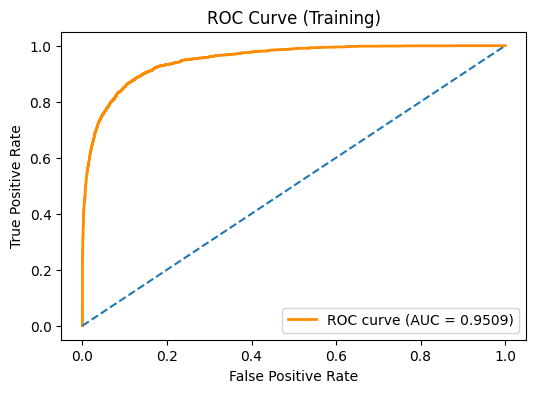

None
AUROC for Validation: 0.9350


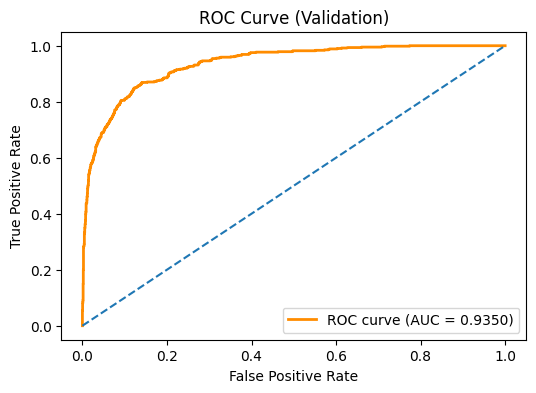

None


In [ ]:
lgbm_clf = lgb.LGBMClassifier(
    max_depth=5,
    n_estimators=50,
    learning_rate=0.1,
    cat_feature=cat_feature_indexes,
)

lgbm_clf.fit(X_train, train_targets)
train_preds = lgbm_clf.predict(X_train)
val_preds = lgbm_clf.predict(X_val)

print(compute_auroc_and_build_roc(lgbm_clf, X_train, train_targets, "Training"))
print(compute_auroc_and_build_roc(lgbm_clf, X_val, val_targets, "Validation"))

Результати покращились зовсім на трішки для валідаційної вибірки порівняно з моделю XGBoost.

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

100%|██████████| 10/10 [00:07<00:00,  1.38trial/s, best loss: -0.9367981343027644]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.779325222567709), 'learning_rate': np.float64(0.029568500354619665), 'max_depth': 3, 'min_child_weight': 11, 'min_split_gain': np.float64(0.01632044186180659), 'n_estimators': 375, 'num_leaves': 24, 'reg_alpha': np.float64(0.1742619572137899), 'reg_lambda': np.float64(0.11914980962089916), 'subsample': np.float64(0.537346567856495)}
Точність на валідаційній вибірці: 0.9368
AUROC for Training: 0.9430


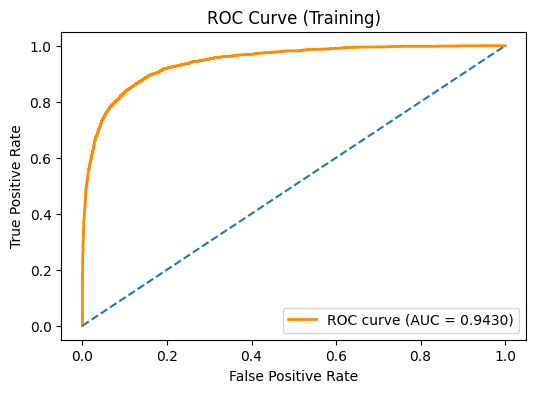

None
AUROC for Validation: 0.9368


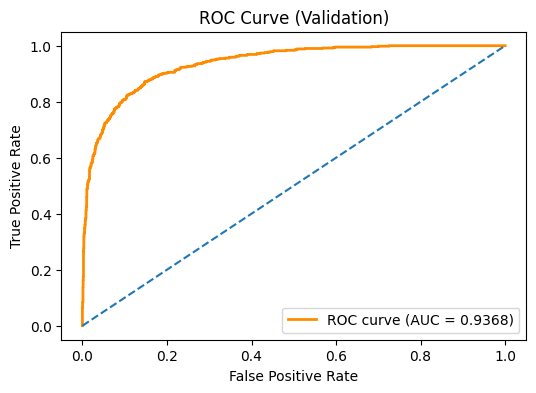

None


In [ ]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),  # Кількість дерев у ансамблі (кількість ітерацій бустингу)
        learning_rate=params['learning_rate'],  # Коефіцієнт, на який зменшується внесок кожного доданого дерева
        max_depth=int(params['max_depth']),  # Максимальна глибина кожного дерева
        num_leaves=int(params['num_leaves']),  # Максимальна кількість листків, що дозволяємо кожному дереву мати.
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        min_split_gain=params['min_split_gain'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        cat_feature=cat_feature_indexes,  # Індекси категорійних ознак
        verbose=-1,
        random_state = 43
    )

    clf.fit(X_train, train_targets, eval_set=[(X_val, val_targets)])
    pred_proba = clf.predict_proba(X_val)[:, 1]
    roc_auc = roc_auc_score(val_targets, pred_proba)

    return {'loss': -roc_auc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 15, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1) # додано мінімальне зменшення втрат для поділу
}

trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials, rstate=np.random.default_rng(43))

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

final_clf = lgb.LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    min_split_gain=best['min_split_gain'],
    cat_feature=cat_feature_indexes,
    verbose=-1,
    random_state = 43
)

final_clf.fit(X_train, train_targets, eval_set=[(X_val, val_targets)])
final_pred_proba = final_clf.predict_proba(X_val)[:, 1]
final_roc_auc = roc_auc_score(val_targets, final_pred_proba)

print("Точність на валідаційній вибірці: {:.4f}".format(final_roc_auc))
print(compute_auroc_and_build_roc(final_clf, X_train, train_targets, "Training"))
print(compute_auroc_and_build_roc(final_clf, X_val, val_targets, "Validation"))

Ця модель показала найкращі результати, дещо збільшивши результат в порівнняні з іншими моделями AUROC for Validation: 0.9368

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

Я обрала фінальну модель, тому що вона показала найкращі результати, та не має ознак перенавчання, трейн auc-roc та valid майже не відрізняються

In [ ]:
test_raw_df = pd.read_csv('/content/drive/MyDrive/dataframes/Bank/test.csv', index_col=0)
test_df = test_raw_df.drop(['CustomerId', 'Surname'], axis = 1)
cat_features = test_df.select_dtypes(include='object').columns
test_df[cat_features] = test_df[cat_features].astype('category')
cat_feature_indexes = [test_df.columns.get_loc(col) for col in cat_features]
test_probs = final_clf.predict_proba(test_df)[:, 1]

In [ ]:
test_probs

array([0.08814038, 0.01543053, 0.05991613, ..., 0.00562326, 0.07371875,
       0.18600422])

In [ ]:
submission_lgbm = pd.read_csv('/content/drive/MyDrive/dataframes/Bank/sample_submission.csv')
submission_lgbm['Exited'] = test_probs
submission_lgbm.head()


,id,Exited
0,15000,0.088140
1,15001,0.015431
2,15002,0.059916
3,15003,0.526060
4,15004,0.034325


In [ ]:
submission_lgbm.to_csv('submission_lgbm.csv', index=False)

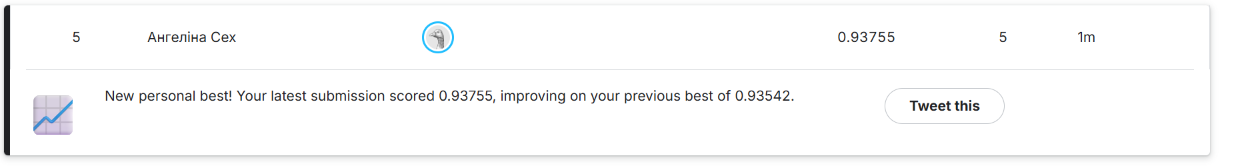